In [14]:
import os

# 1. Inject the Kaggle API Token directly into Colab system memory
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_101a7e757941872c8e005a44b78e4b34'

# 2. Make sure the newest client package is installed
!pip install -q kaggle

# 3. Download the specific Digit Recognizer competition files
!kaggle competitions download -c digit-recognizer

# 4. Unzip the data into your workspace
!unzip -o digit-recognizer.zip

# 5. Check to make sure train.csv and test.csv are visible
print("\n📁 Current files in /content:")
print(os.listdir())


digit-recognizer.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  digit-recognizer.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               

📁 Current files in /content:
['.config', 'test.csv', 'digit-recognizer.zip', 'sample_submission.csv', 'train.csv', 'sample_data']


📍 Working directory verified at: /content
⏳ Loading Digit Recognizer Data...
✅ Files loaded successfully!
✅ Train Shape: (42000, 785) | Test Shape: (28000, 784)
🔍 Missing Values -> Train: 0, Test: 0


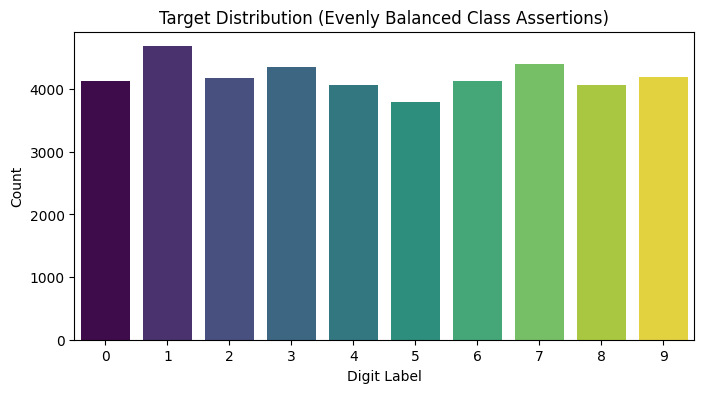

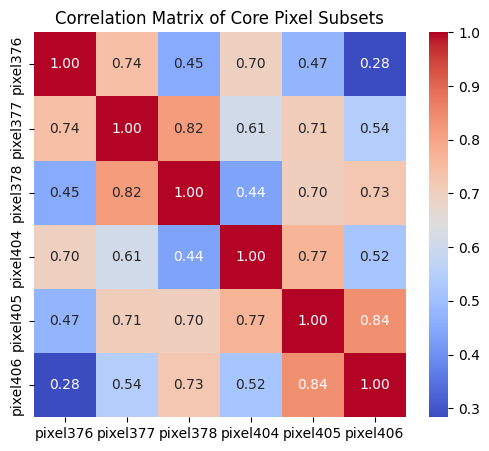

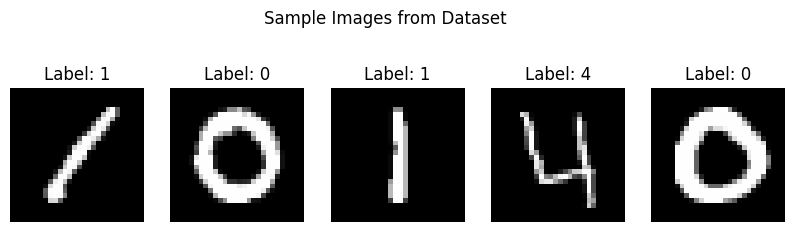

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. AUTO-DIRECTORY FIX: Ensure Python points to where the Kaggle files live
if os.path.exists('/content'):
    os.chdir('/content')
print(f"📍 Working directory verified at: {os.getcwd()}")

# 2. Load Data Safely
print("⏳ Loading Digit Recognizer Data...")
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    print("✅ Files loaded successfully!")
except FileNotFoundError:
    print("❌ Files not found in current directory. Checking alternative paths...")
    # Search common download locations
    if os.path.exists('digit-recognizer.zip'):
        print("📦 Found zip file. Unzipping data now...")
        !unzip -o digit-recognizer.zip
        train_df = pd.read_csv('train.csv')
        test_df = pd.read_csv('test.csv')
    else:
        raise FileNotFoundError("Could not find train.csv or test.csv. Please verify the Kaggle download cell ran successfully.")

# 3. Check Dimensions & Missing Values
print(f"✅ Train Shape: {train_df.shape} | Test Shape: {test_df.shape}")
missing_train = train_df.isnull().sum().sum()
missing_test = test_df.isnull().sum().sum()
print(f"🔍 Missing Values -> Train: {missing_train}, Test: {missing_test}")

# 4. Analyze Target Class Distributions
plt.figure(figsize=(8, 4))
# Fixed palette warning for newer seaborn versions by explicitly setting hue
sns.countplot(x='label', data=train_df, hue='label', palette='viridis', legend=False)
plt.title('Target Distribution (Evenly Balanced Class Assertions)')
plt.xlabel('Digit Label')
plt.ylabel('Count')
plt.show()

# 5. Feature Space Core Correlation (Sampling active central pixels)
# 🌟 FIXED: Explicitly listed the string labels to prevent loop parsing errors
central_pixels = ['pixel376', 'pixel377', 'pixel378', 'pixel404', 'pixel405', 'pixel406']
corr = train_df[central_pixels].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Core Pixel Subsets')
plt.show()

# 6. Visual Rendering Baseline
X_samples = train_df.drop(columns=['label']).values.reshape(-1, 28, 28)
y_samples = train_df['label'].values

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_samples[i], cmap='gray')
    ax.set_title(f"Label: {y_samples[i]}")
    ax.axis('off')
plt.suptitle("Sample Images from Dataset")
plt.show()


In [16]:
# Install timm library safely
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
import numpy as np
# 🌟 FIXED: Changed 'model_split' to 'model_selection'
from sklearn.model_selection import train_test_split

# 1. Create Custom PyTorch Dataset Mapper
class MNISTDataset(Dataset):
    def __init__(self, df, is_test=False):
        if not is_test:
            self.labels = df['label'].values
            self.features = df.drop(columns=['label']).values.astype(np.float32)
        else:
            self.labels = None
            self.features = df.values.astype(np.float32)

        # Normalize 0-255 pixels down to 0.0-1.0 interval bounds
        self.features = self.features / 255.0
        # Reshape to (Batch, Channel, Height, Width) -> (N, 1, 28, 28)
        self.features = self.features.reshape(-1, 1, 28, 28)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        X = torch.tensor(self.features[idx])
        if self.labels is not None:
            y = torch.tensor(self.labels[idx], dtype=torch.long)
            return X, y
        return X

# 2. Split data into Train and Validation chunks
train_split, val_split = train_test_split(train_df, test_size=0.15, random_state=42, stratify=train_df['label'])

train_ds = MNISTDataset(train_split)
val_ds = MNISTDataset(val_split)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

# 3. Model Orchestration: Modify Pretrained ResNet18
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using processing execution platform: {device}")

# Fetch ResNet18 structure template
model = timm.create_model('resnet18', pretrained=False, num_classes=10)

# Re-architect the input layer: Adapt 3-channel Conv1 to accept 1-channel grayscale arrays
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
print("✅ ResNet18 customized architecture complete.")


🖥️ Using processing execution platform: cpu
✅ ResNet18 customized architecture complete.


In [17]:
print("🚀 Launching Fast Baseline Execution Loop...")
model.train()

for epoch in range(1): # Single execution cycle for rapid prototyping proof
    running_loss = 0.0
    correct = 0
    total = 0

    for step, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if step % 100 == 0:
            print(f"Batch {step}/{len(train_loader)} | Training Loss: {loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    print(f"\n📊 [TRAIN FINISHED] Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

# Quick Validation Run
model.eval()
val_correct = 0
val_total = 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        val_total += labels.size(0)
        val_correct += predicted.eq(labels).sum().item()

print(f"🎯 [VALIDATION METRICS] Out-of-Sample Accuracy: {(val_correct / val_total)*100:.2f}%")


🚀 Launching Fast Baseline Execution Loop...
Batch 0/279 | Training Loss: 2.3607
Batch 100/279 | Training Loss: 0.0875
Batch 200/279 | Training Loss: 0.0381

📊 [TRAIN FINISHED] Loss: 0.1787 | Accuracy: 94.90%
🎯 [VALIDATION METRICS] Out-of-Sample Accuracy: 97.08%


In [18]:
# Save weights to native PyTorch serialization formats (.pt)
weight_output_path = "resnet18_mnist_baseline.pt"
torch.save(model.state_dict(), weight_output_path)

print(f"📦 Model weights successfully serialized and exported to: '{weight_output_path}'")
print("🔗 Check your left sidebar File Explorer folder inside Colab to download it locally.")


📦 Model weights successfully serialized and exported to: 'resnet18_mnist_baseline.pt'
🔗 Check your left sidebar File Explorer folder inside Colab to download it locally.


In [23]:
import os
from google.colab import files

# 1. Print current location to debug where Python is looking
print(f"Python is currently working in: {os.getcwd()}")

# 2. Check if the file exists in the standard '/content' directory
absolute_path = "/content/resnet18_mnist_baseline.pt"

if os.path.exists(absolute_path):
    print("Code verified! The file exists perfectly inside /content.")
    print("Triggering direct browser download window now...")
    files.download(absolute_path)
elif os.path.exists("resnet18_mnist_baseline.pt"):
    print("Code verified! The file exists in your current relative directory.")
    print("Triggering direct browser download window now...")
    files.download("resnet18_mnist_baseline.pt")
else:
    print("Cannot find the file anywhere. Please re-run Cell 4 to generate it!")


Python is currently working in: /content
Code verified! The file exists perfectly inside /content.
Triggering direct browser download window now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Inference running on platform: cpu
loaded saved model weights directly from the file system


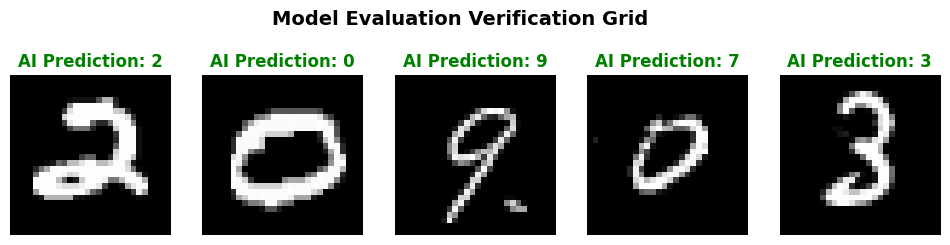

In [26]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import timm

# 1. Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Inference running on platform: {device}")

# 2. Recreate the precise model framework
inference_model = timm.create_model('resnet18', pretrained=False, num_classes=10)
inference_model.conv1 = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# 3. 💾 LOAD THE WEIGHTS FROM THE FILE (Bypassing training loops!)
weights_path = "/content/resnet18_mnist_baseline.pt"
try:
    inference_model.load_state_dict(torch.load(weights_path, map_location=device))
    print("loaded saved model weights directly from the file system")
except FileNotFoundError:
    # Fallback to local working folder path check
    inference_model.load_state_dict(torch.load("resnet18_mnist_baseline.pt", map_location=device))
    print(" Loaded saved model weights from local path")

inference_model.to(device)
inference_model.eval()

# 4. Pull 5 fresh images from test.csv
test_df = pd.read_csv('test.csv')
raw_test_samples = test_df.iloc[:5].values
processed_samples = (raw_test_samples / 255.0).astype(np.float32).reshape(-1, 1, 28, 28)
tensor_test_samples = torch.tensor(processed_samples).to(device)

# 5. Generate Predictions using the loaded weights
with torch.no_grad():
    outputs = inference_model(tensor_test_samples)
    predictions = outputs.argmax(dim=1).cpu().numpy()

# 6. Display the Visual Proof for the screen recording
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(raw_test_samples[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"AI Prediction: {predictions[i]}", color='green', fontweight='bold')
    ax.axis('off')
plt.suptitle("Model Evaluation Verification Grid", fontsize=14, fontweight='bold')
plt.show()
